# Three-body check: does a pairwise model capture third-order team structure?

**Diagnostic question.** Everything downstream of the inverse Ising fits rests on the assumption that team structure is captured by *pairs* — the model family
$$P(s) \propto \exp\Big(h\cdot s + \tfrac{1}{2}\, s' J s\Big), \qquad \textstyle\sum_i s_i = 6,$$
has no three-body terms, so any genuine third-order structure in team building (cores of three that appear together *beyond what their pairwise couplings explain*) is invisible to it. This notebook measures that directly.

**Statistic.** The connected three-point correlation
$$T_{ijk} = \big\langle (s_i - m_i)(s_j - m_j)(s_k - m_k) \big\rangle$$
(the central third mixed moment). For a pairwise model $T_{ijk}$ is **not** zero — the couplings and the fixed team size both induce three-point correlations — so the test is **model-sampled vs. empirical** $T_{ijk}$, both living on the same six-member manifold, *not* "empirical vs. zero".

**Design.**

- Fit both production weighted models (species and species@item) on the **full corpus**. The question is whether the model *family* reproduces third moments of the data it was fit to, so in-sample is the right comparison (no generalization claim is being made).
- Sample teams from each fitted model with the production PT machinery (cold chain at $T=1$, `field_weight = 1`), then compare sampled vs. empirical $T_{ijk}$ on the top-$K$ features by weighted usage.
- Empirical moments use the same per-team fit weights as the fit itself, so "empirical" means *what the fit saw*. Model moments are unweighted over PT samples.
- Surface the worst-violating triplets: those are the specific cores a richer (three-body) model would need.


In [1]:
from __future__ import annotations

import itertools

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from k2dex import tournament_ingest
from k2dex.constants import TEAM_SIZE
from k2dex.loaders import build_species_model, build_species_item_model, team_weights
from k2dex.sampling import parallel_tempered_mcmc

tournaments = tournament_ingest.load_cached_tournaments()
observations = tournament_ingest.all_team_observations(tournaments)
print(f"tournaments: {len(tournaments)}")
print(f"teams:       {len(observations)}")


tournaments: 187
teams:       21916


## Production weighted fits

Both models use the v1.1 weighted-fit knobs (τ = 30 d recency decay, in-person multiplier, λ from the post-weighting sweeps): species at (τ=30, ×3, λ=30); species@item at (τ=30, ×2, λ=3), matching the shipped `reg-m-a-species-item-weighted` artifact. The same per-team weights are rebuilt here for the empirical moments.


In [2]:
SP_TAU, SP_MULT, SP_LAM = 30.0, 3.0, 30.0
PR_TAU, PR_MULT, PR_LAM = 30.0, 2.0, 3.0

(vocab_sp, m_sp, J_sp, h_sp, _, _, _, latest_sp) = build_species_model(
    lam=SP_LAM, recency_tau=SP_TAU, in_person_multiplier=SP_MULT,
)
w_sp = team_weights(observations, reference_date=latest_sp,
                    recency_tau=SP_TAU, in_person_multiplier=SP_MULT)

sp_to_idx = {name: i for i, name in enumerate(vocab_sp)}
X_sp = np.zeros((len(observations), len(vocab_sp)), dtype=np.int8)
for ti, obs in enumerate(observations):
    for species, _item in obs.members:
        j = sp_to_idx.get(species)
        if j is not None:
            X_sp[ti, j] = 1

assert np.allclose((w_sp @ X_sp) / w_sp.sum(), m_sp, atol=1e-12)
print(f"species model:      V={len(vocab_sp):4d}  N={X_sp.shape[0]}")


species model:      V= 183  N=21916


In [3]:
(vocab_pr, m_pr, J_pr, h_pr, _, species_of_pr, item_of_pr,
 latest_pr) = build_species_item_model(
    lam=PR_LAM, recency_tau=PR_TAU, in_person_multiplier=PR_MULT,
)
w_pr = team_weights(observations, reference_date=latest_pr,
                    recency_tau=PR_TAU, in_person_multiplier=PR_MULT)

pair_to_idx = {(s, it): i
               for i, (s, it) in enumerate(zip(species_of_pr, item_of_pr))}
X_pr = np.zeros((len(observations), len(vocab_pr)), dtype=np.int8)
for ti, obs in enumerate(observations):
    for pair in obs.members:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_pr[ti, j] = 1

assert np.allclose((w_pr @ X_pr) / w_pr.sum(), m_pr, atol=1e-12)
print(f"species@item model: V={len(vocab_pr):4d}  N={X_pr.shape[0]}")


species@item model: V= 635  N=21916


## Sampling the fitted models

Production sampler (`parallel_tempered_mcmc`), geometric ladder from $T=1$ (cold, collected) to $T_{\max}=2$, replica-exchange every 10 sweeps. The cold chain samples $P(s)$ on the legal-team manifold — six members, and for the pair model additionally no duplicate species / items via the sampler's uniqueness constraints. That manifold is exactly where the corpus lives, so empirical and model moments share a support.

Multiple independent runs; cold chains thinned and pooled. Thinned samples retain some autocorrelation (one swap move changes one slot), so model-side standard errors below are mildly optimistic — the empirical side dominates the error budget at these sample sizes anyway.

This cell is the slow one (several minutes per model); reduce `N_RUNS` / `N_STEPS` for a quick pass.


In [ ]:
K_LADDER = 8
T_MIN, T_MAX = 0.5, 3.0
SWAP_INTERVAL = 10
N_RUNS = 25
N_STEPS = 100_000
BURN_IN = 10_000
THIN = 25


def sample_model(J, h, *, species_of=None, item_of=None, seed0=0):
    ladder = np.geomspace(T_MIN, T_MAX, K_LADDER)
    rng = np.random.default_rng(seed0)
    pooled, local_rates, swap_rates = [], [], []
    for _ in range(N_RUNS):
        result = parallel_tempered_mcmc(
            J, h, TEAM_SIZE, [], [], 1.0,
            ladder, N_STEPS, BURN_IN, SWAP_INTERVAL,
            int(rng.integers(2**31)),
            species_of=species_of, item_of=item_of,
        )
        assert result is not None
        samples, local_rate, swap_rate = result
        pooled.append(samples[::THIN])
        local_rates.append(local_rate)
        swap_rates.append(swap_rate)
    S = np.concatenate(pooled)
    print(f"  samples={S.shape[0]}  local acc={np.mean(local_rates):.3f}"
          f"  swap acc={np.mean(swap_rates):.3f}")
    return S


print("species model:")
S_sp = sample_model(J_sp, h_sp, seed0=1)


species model:
  samples=36000  local acc=0.200  swap acc=0.570


In [5]:
print("species@item model:")
S_pr = sample_model(J_pr, h_pr,
                    species_of=species_of_pr, item_of=item_of_pr, seed0=2)


species@item model:
  samples=36000  local acc=0.236  swap acc=0.522


## Moment estimators

With normalized weights $W_n = w_n / \sum_n w_n$ and centered features $\tilde x_{ni} = x_{ni} - \mu_i$:

$$\hat T_{ijk} = \sum_n W_n\, \tilde x_{ni}\,\tilde x_{nj}\,\tilde x_{nk},
\qquad
\mathrm{SE}^2\big(\hat T_{ijk}\big) \approx \Big(\textstyle\sum_n W_n^2\Big)\Big(\textstyle\sum_n W_n\, g_n^2 - \hat T_{ijk}^2\Big),
\quad g_n = \tilde x_{ni}\,\tilde x_{nj}\,\tilde x_{nk}.$$

Model-side estimates use the same formulas with uniform weights over PT samples. The per-triplet comparison statistic is

$$z_{ijk} = \frac{\hat T^{\mathrm{emp}}_{ijk} - \hat T^{\mathrm{model}}_{ijk}}{\sqrt{\mathrm{SE}^2_{\mathrm{emp}} + \mathrm{SE}^2_{\mathrm{model}}}},$$

restricted to the top-$K$ features by weighted marginal — third moments of rare features are noise-dominated on both sides. The connected two-point comparison is shown alongside as the calibration reference: the L2-regularized PL fit does not match $C_{ij}$ exactly, and whatever two-point shortfall exists propagates into the three-point prediction. Attribute a triplet to "missing three-body physics" only when it stands out *relative to* the two-point panel.


In [6]:
K_TOP = 60


def triple_product_mean(A, W):
    """M[i,j,k] = sum_n W_n A[n,i] A[n,j] A[n,k]  (W sums to 1)."""
    K = A.shape[1]
    out = np.empty((K, K, K))
    Aw = A * W[:, None]
    for i in range(K):
        out[i] = (A * Aw[:, [i]]).T @ A
    return out


def connected_moments(X, w, idx):
    """Weighted mean, connected 2-point, connected 3-point + per-triplet SE,
    restricted to the feature subset `idx`."""
    W = w / w.sum()
    Xs = X[:, idx].astype(np.float64)
    mu = W @ Xs
    Xc = Xs - mu
    C = (Xc * W[:, None]).T @ Xc
    T = triple_product_mean(Xc, W)
    G2 = triple_product_mean(Xc**2, W)
    se = np.sqrt(np.clip((W @ W) * (G2 - T**2), 0.0, None))
    return mu, C, T, se


def compare_three_body(X_emp, w_emp, samples, m_weighted, vocab, label):
    idx = np.argsort(m_weighted)[::-1][:K_TOP]
    names = [vocab[i] for i in idx]
    mu_e, C_e, T_e, se_e = connected_moments(X_emp, w_emp, idx)
    mu_m, C_m, T_m, se_m = connected_moments(
        samples, np.ones(samples.shape[0]), idx)

    pairs = np.array(list(itertools.combinations(range(K_TOP), 2)))
    trips = np.array(list(itertools.combinations(range(K_TOP), 3)))
    c_e = C_e[pairs[:, 0], pairs[:, 1]]
    c_m = C_m[pairs[:, 0], pairs[:, 1]]
    t_e = T_e[trips[:, 0], trips[:, 1], trips[:, 2]]
    t_m = T_m[trips[:, 0], trips[:, 1], trips[:, 2]]
    s_e = se_e[trips[:, 0], trips[:, 1], trips[:, 2]]
    s_m = se_m[trips[:, 0], trips[:, 1], trips[:, 2]]
    z = (t_e - t_m) / np.sqrt(s_e**2 + s_m**2)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    ax = axes[0, 0]
    ax.scatter(mu_e, mu_m, s=12, alpha=0.7)
    lim = max(mu_e.max(), mu_m.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlabel("empirical $m_i$ (weighted)")
    ax.set_ylabel("model $m_i$")
    ax.set_title(f"marginals  r={np.corrcoef(mu_e, mu_m)[0, 1]:.4f}")

    ax = axes[0, 1]
    ax.scatter(c_e, c_m, s=4, alpha=0.4)
    lo, hi = min(c_e.min(), c_m.min()), max(c_e.max(), c_m.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_xlabel("empirical $C_{ij}$")
    ax.set_ylabel("model $C_{ij}$")
    ax.set_title(f"connected 2-point  r={np.corrcoef(c_e, c_m)[0, 1]:.4f}")

    ax = axes[1, 0]
    ax.scatter(t_e, t_m, s=2, alpha=0.25)
    lo, hi = min(t_e.min(), t_m.min()), max(t_e.max(), t_m.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_xlabel("empirical $T_{ijk}$")
    ax.set_ylabel("model $T_{ijk}$")
    ax.set_title(f"connected 3-point  r={np.corrcoef(t_e, t_m)[0, 1]:.4f}")

    ax = axes[1, 1]
    ax.hist(z, bins=80, density=True, alpha=0.7)
    grid = np.linspace(-6, 6, 200)
    ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "k-", lw=1)
    ax.set_xlabel("$z_{ijk}$")
    ax.set_title("3-point residuals vs. N(0,1)")
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

    frac3 = float(np.mean(np.abs(z) > 3))
    frac5 = float(np.mean(np.abs(z) > 5))
    print(f"{label}: {len(trips)} triplets over top {K_TOP} features")
    print(f"  corr(T_emp, T_model) = {np.corrcoef(t_e, t_m)[0, 1]:.4f}")
    print(f"  |z|>3: {frac3:.3%} (N(0,1) expects 0.270%)   |z|>5: {frac5:.3%}")
    return {"names": names, "trips": trips, "t_e": t_e, "t_m": t_m, "z": z}


def worst_triplets_table(res, n=15):
    order = np.argsort(-np.abs(res["z"]))[:n]
    lines = [
        "| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |",
        "| :-- | :-- | :-- | --: | --: | --: |",
    ]
    for o in order:
        i, j, k = res["trips"][o]
        lines.append(
            f"| {res['names'][i]} | {res['names'][j]} | {res['names'][k]} "
            f"| {res['t_e'][o]:+.5f} | {res['t_m'][o]:+.5f} | {res['z'][o]:+.1f} |"
        )
    display(Markdown("\n".join(lines)))


## Species model


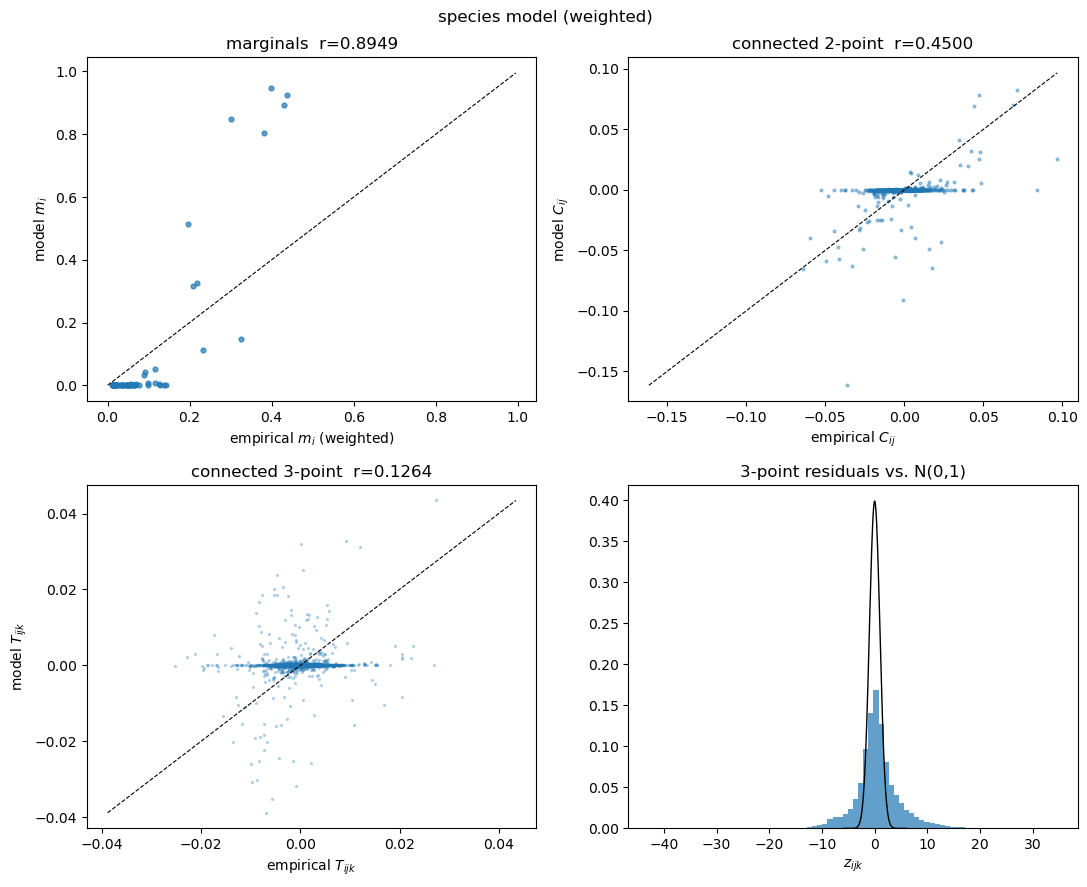

species model (weighted): 34220 triplets over top 60 features
  corr(T_emp, T_model) = 0.1264
  |z|>3: 33.828% (N(0,1) expects 0.270%)   |z|>5: 19.234%


| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Eternal Flower Floette | Aerodactyl | Whimsicott | +0.00014 | +0.03205 | -42.9 |
| Sinistcha | Aerodactyl | Whimsicott | +0.01201 | +0.03115 | -41.3 |
| Incineroar | Aerodactyl | Whimsicott | +0.00923 | +0.03275 | -37.6 |
| Charizard | Pelipper | Tyranitar | +0.00640 | +0.00000 | +34.6 |
| Incineroar | Sinistcha | Whimsicott | -0.00567 | -0.03513 | +33.0 |
| Charizard | Pelipper | Delphox | +0.00417 | +0.00000 | +32.2 |
| Charizard | Archaludon | Delphox | +0.00444 | +0.00000 | +32.0 |
| Aerodactyl | Whimsicott | Pelipper | +0.00795 | +0.00014 | +31.9 |
| Garchomp | Archaludon | Kommo-O | +0.00580 | +0.00000 | +31.1 |
| Charizard | Pelipper | Froslass | +0.00578 | +0.00002 | +30.9 |
| Kingambit | Archaludon | Tyranitar | +0.00824 | +0.00000 | +30.8 |
| Kingambit | Pelipper | Tyranitar | +0.00708 | +0.00000 | +30.6 |
| Charizard | Pelipper | Corviknight | +0.00428 | +0.00000 | +30.3 |
| Eternal Flower Floette | Sylveon | Gardevoir | +0.00224 | +0.00001 | +30.1 |
| Charizard | Pelipper | Politoed | +0.00277 | +0.00000 | +30.0 |

In [7]:
res_sp = compare_three_body(X_sp, w_sp, S_sp, m_sp, vocab_sp,
                            "species model (weighted)")
worst_triplets_table(res_sp)


## Species@item model


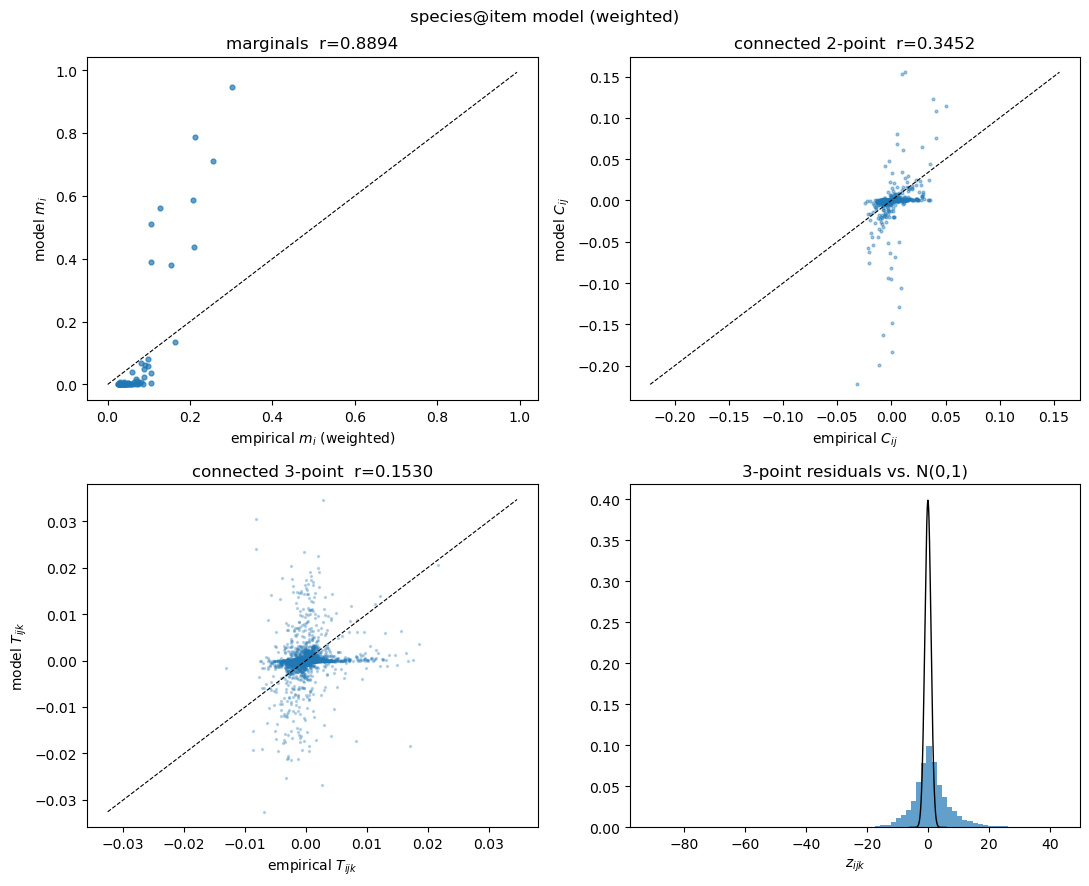

species@item model (weighted): 34220 triplets over top 60 features
  corr(T_emp, T_model) = 0.1530
  |z|>3: 50.903% (N(0,1) expects 0.270%)   |z|>5: 33.065%


| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Aerodactyl @ Focus Sash | Whimsicott @ Focus Sash | Aerodactyl @ Aerodactylite | +0.00200 | +0.02252 | -91.2 |
| Aerodactyl @ Focus Sash | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | +0.00195 | +0.02000 | -85.2 |
| Charizard @ Charizardite Y | Incineroar @ Sitrus Berry | Garchomp @ Sitrus Berry | -0.00817 | +0.03038 | -53.5 |
| Basculegion @ Choice Scarf | Garchomp @ Sitrus Berry | Garchomp @ Choice Scarf | +0.00278 | +0.03462 | -53.3 |
| Eternal Flower Floette @ Floettite | Whimsicott @ Focus Sash | Aerodactyl @ Aerodactylite | +0.00085 | +0.01722 | -51.6 |
| Incineroar @ Sitrus Berry | Garchomp @ Sitrus Berry | Sinistcha @ Sitrus Berry | +0.00367 | +0.00949 | -47.1 |
| Eternal Flower Floette @ Floettite | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | +0.00026 | +0.01429 | -46.8 |
| Basculegion @ Choice Scarf | Aerodactyl @ Focus Sash | Basculegion @ Mystic Water | +0.00071 | +0.01900 | -43.7 |
| Eternal Flower Floette @ Floettite | Sylveon @ Fairy Feather | Whimsicott @ Focus Sash | +0.00132 | +0.01358 | -43.3 |
| Incineroar @ Sitrus Berry | Sinistcha @ Sitrus Berry | Farigiraf @ Sitrus Berry | +0.00238 | +0.00013 | +43.2 |
| Garchomp @ Sitrus Berry | Whimsicott @ Focus Sash | Aerodactyl @ Aerodactylite | -0.00238 | -0.01672 | +41.6 |
| Incineroar @ Sitrus Berry | Whimsicott @ Focus Sash | Sinistcha @ Sitrus Berry | +0.00156 | +0.00753 | -41.2 |
| Garchomp @ Sitrus Berry | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | -0.00253 | -0.01515 | +41.0 |
| Whimsicott @ Focus Sash | Basculegion @ Focus Sash | Sneasler @ Focus Sash | +0.00136 | +0.00002 | +40.9 |
| Aerodactyl @ Focus Sash | Basculegion @ Focus Sash | Sneasler @ Focus Sash | +0.00137 | +0.00001 | +40.9 |

In [8]:
res_pr = compare_three_body(X_pr, w_pr, S_pr, m_pr, vocab_pr,
                            "species@item model (weighted)")
worst_triplets_table(res_pr)


## Reading the result

- **3-point scatter hugging the diagonal, $z$ roughly N(0,1).** The pairwise family reproduces third-order structure it was never fit to — the assumption is earned. Natural next step: the `/science` writeup (a pairwise MaxEnt model *predicting* three-point functions is the textbook validation move, cf. Schneidman et al. on retinal populations).
- **Tight diagonal except a handful of large-$|z|$ triplets.** Pairwise is fine in bulk; the listed triplets are the specific cores that would need a three-body term. Per the v2 plan this names them publicly — no architecture change either way.
- **Broad miscalibration** (3-point slope far from 1 *while the 2-point panel is tight*). Genuine evidence against the pairwise assumption; before believing it, re-check sampler convergence (acceptance rates above, try doubling `N_STEPS`) and the $K$-truncation.

Caveats: in-sample by design; top-$K$ truncation hides rare-feature triplets; model-side SEs slightly optimistic (residual chain autocorrelation); the L2 regularizer shrinks $J$, so part of any 3-point shortfall is inherited from the 2-point shortfall — compare panels before attributing discrepancy to missing three-body physics.
